<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter07_%EA%B5%B0%EC%A7%91%ED%99%94_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (2).ttf


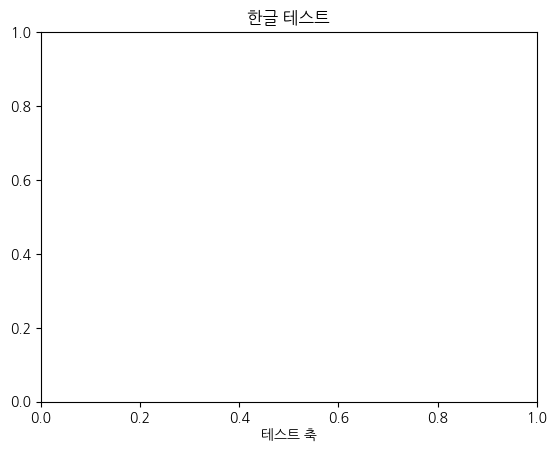

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
#환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

###  K-평균 (K-Means)
[K-Means 동작 원리]
1. K개의 초기 중심점 설정 (k-means++ 방식으로 서로 멀리 떨어지게)
2. 각 데이터를 가장 가까운 중심점의 군집으로 할당
3. 군집에 속한 데이터들의 평균으로 중심점 업데이트
4. 중심점 변화가 없을 때까지 2~3 반복

[K-Means 핵심 특징]
* 사전에 K값(군집 수)을 지정해야 함
* 원형(구형) 군집에 최적화 → 타원형·동심원에 취약
* 이상치에 민감 (중심점이 이상치 방향으로 당겨짐)
* 가장 빠르고 확장성 좋은 군집화 알고리즘

In [ ]:
from sklearn.datasets import load_iris, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler, scale
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

iris = load_iris()
irisDF = pd.DataFrame(
    data=iris.data,
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

In [ ]:
kmeans = KMeans(
    n_clusters=3, ## 군집 수 K
    init = 'k-means++', # 중심점을 서로 멀리 떨어지게 초기화, random: 완전 무작위
    max_iter=300, # 최대 반복 횟수
    random_state=0
)
kmeans.fit(irisDF) # 비지도 학습(Unsupervised Learning)
print('군집 레이블 (처음 10개):', kmeans.labels_[:10]) # 각 데이터 포인트에 할당된 군집 번호 (0, 1, 2)
print('군집 레이블 종류:', np.unique(kmeans.labels_)) # 현재 데이터에 존재하는 고유한 군집 번호
print('군집 중심 좌표 shape:', kmeans.cluster_centers_.shape) # (K, 피처수) = (3, 4)
#kmeans.cluster_centers_ : 각 군집의 중심점(controid) 좌표를 담고 있는 배열

군집 레이블 (처음 10개): [1 1 1 1 1 1 1 1 1 1]
군집 레이블 종류: [0 1 2]
군집 중심 좌표 shape: (3, 4)


In [ ]:
# 군집 결과 vs 실제 레이블 비교
irisDF['target'] = iris.target # 실제 레이블 (0=setoas, 1=versicolor, 2=virginica)
irisDF['cluster'] = kmeans.labels_ # K_means 군집 번호 (0, 1, 2)

iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print('=== target X cluster 분포 ===')
print(iris_result)
# 0=setosa는 하나의 군집에 완벽 분리
# 1=versicolor는 0번 군집에 47에 속하고 2번 군집에 3개의 데이터가 속함
# 2=virginica는 2번 군집에 36개 데이터가 속하고 0번 군집에 14개의 데이터가 속

=== target X cluster 분포 ===
target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


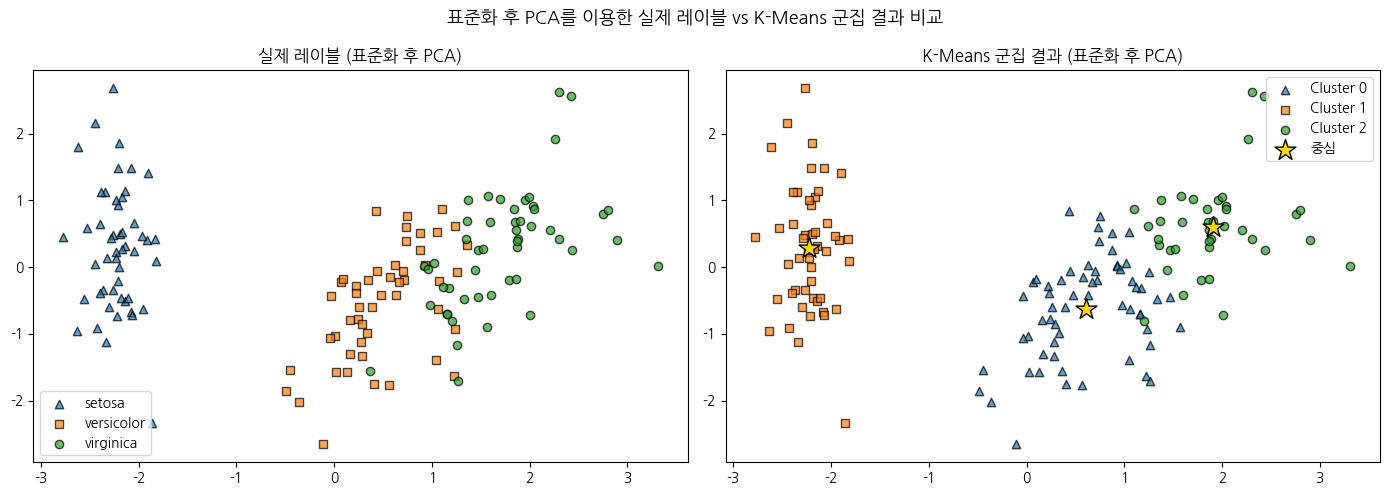

In [ ]:
# PCA로 피처 4차원 -> 2차원 축소 후 군집 결과 시각화

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data)

pca_scaled = PCA(n_components=2, random_state=0)
pca_transformed_scaled = pca_scaled.fit_transform(iris_scaled) #PC1, PC2

irisDF_scaled = irisDF.copy()
irisDF_scaled['pca_x_scaled'] = pca_transformed_scaled[:, 0]
irisDF_scaled['pca_y_scaled'] = pca_transformed_scaled[:, 1]

irisDF_scaled['cluster'] = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 왼쪽 : 실제 레이블
for i, (marker, label) in enumerate(zip(['^', 's', 'o'], iris.target_names)):
  mask = irisDF_scaled['target'] == i
  axes[0].scatter(irisDF_scaled.loc[mask, 'pca_x_scaled'], irisDF_scaled.loc[mask, 'pca_y_scaled'],
                marker=marker, label=label, edgecolor='k', alpha=0.7)
axes[0].set_title('실제 레이블 (표준화 후 PCA)')
axes[0].legend()

# 오른쪽 : K-Means 군집 결과
for i, marker in enumerate(['^', 's', 'o']):
  mask = irisDF_scaled['cluster'] == i
  axes[1].scatter(irisDF_scaled.loc[mask, 'pca_x_scaled'], irisDF_scaled.loc[mask, 'pca_y_scaled'],
                  marker=marker, label= f'Cluster {i}', edgecolor='k', alpha=0.7)
#K--Means 클러스터링의 중심점(kmeans.cluster_centers_)을 표준화 -> PCA
centers_pca_scaled = pca_scaled.transform(scaler.transform(kmeans.cluster_centers_))
axes[1].scatter(centers_pca_scaled[:,0], centers_pca_scaled[:,1], # x-좌표(제1 주성분), y좌표(제2 주성분)
                s=250, c='gold', edgecolor='k', marker='*',zorder=5, label='중심')
axes[1].set_title('K-Means 군집 결과 (표준화 후 PCA)')
axes[1].legend()

plt.suptitle('표준화 후 PCA를 이용한 실제 레이블 vs K-Means 군집 결과 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 군집 평가 -  실루엣 분석
 실루엣 계수 = (다른 군집까지 거리 - 같은 군집 내 거리) / max(둘 중 큰 값)
 범위: -1 ~ 1  |  1에 가까울수록 좋음

* 1에 가까울수록: 데이터 포인트가 자신의 군집에 잘 할당되었고, 다른 군집과도 멀리 떨어져 잘 분리되어 있음을 의미
* 0에 가까울수록: 데이터 포인트가 두 군집의 경계에 위치하여 모호하게 할당되었음을 의미
* -1에 가까울수록: 데이터 포인트가 잘못된 군집에 할당되었을 가능성이 높음을 의미

[좋은 군집화의 조건]
* 평균 실루엣 스코어가 높을 것 (0.5 이상 권장)
* 군집별 실루엣 값이 평균보다 모두 크고 균일할 것

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples
# 개별 데이터 실루엣 계수 계산
score_samples = silhouette_samples(iris.data, irisDF['cluster']) # 각 데이터 포인트의 실루엣 계수를 개별로 반환
print('실루엣 계수 배열 shape:', score_samples.shape)
irisDF['silhouette_coeff'] = score_samples

# 전체 평균 실루엣 스코어
average_score = silhouette_score(iris.data, irisDF['cluster'])
print(f'전체 평균 실루엣 스코어: {average_score:.3f}')

print('\n=== 군집별 평균 실루엣 계수 ===')
print(irisDF.groupby('cluster')['silhouette_coeff'].mean())

실루엣 계수 배열 shape: (150,)
전체 평균 실루엣 스코어: 0.551

=== 군집별 평균 실루엣 계수 ===
cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coeff, dtype: float64


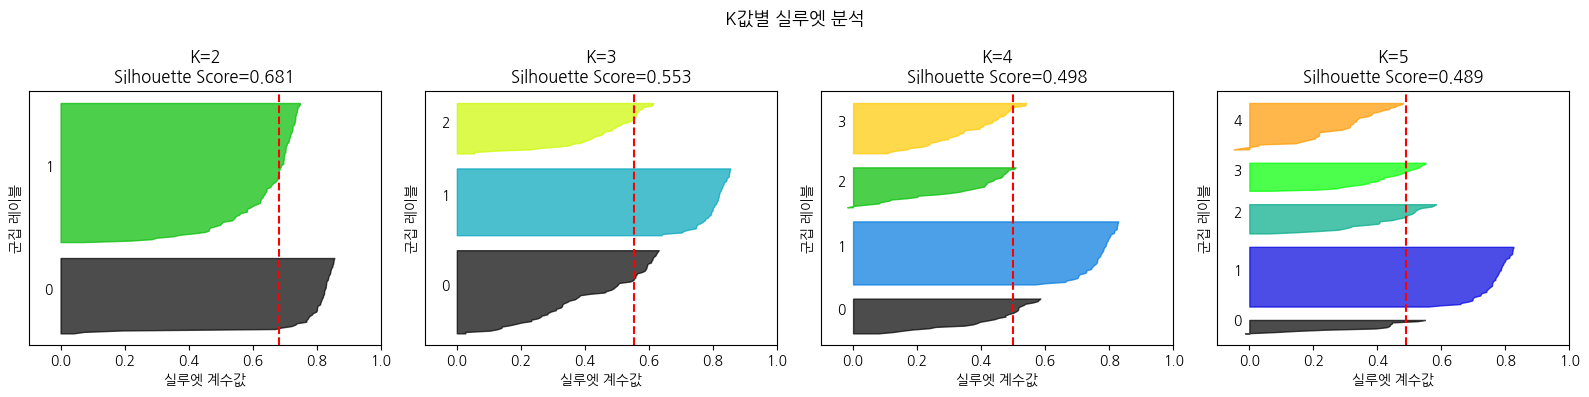

In [ ]:
import matplotlib.cm as cm # 컬러맵(colormap)

# 붗꽃 데이터로 최적 k 탐색
def visualize_silhouette(cluster_lists, X_features):
  n_cols = len(cluster_lists)
  fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

  for ind, n_cluster in enumerate(cluster_lists):
    # Add n_init parameter to KMeans to suppress future warnings
    clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init=10)
    cluster_labels = clusterer.fit_predict(X_features)
    # .fit() 최적의 군집 중심점을 찾고 각 데이터 포인트를 군집에 할당.predict()각 데이터 포인트가 어떤 군집에 속하는지 여
    # cluster_labels : 각 데이터 포인트에 할단된 군집번호(예:0. 1. 2 등)를 담고 있는 배열
    sil_avg = silhouette_score(X_features, cluster_labels)# 전체 데이터 포인트에 대한 실루엣 계수의 평균
    sil_values = silhouette_samples(X_features, cluster_labels)#각 데이터 포인트 순서에 맞춰 해당 데이터의 실루엣 계수

    # Correct f-string for title
    axs[ind].set_title(f'K={n_cluster}\nSilhouette Score={sil_avg:.3f}')
    axs[ind].set_xlabel('실루엣 계수값')
    axs[ind].set_ylabel('군집 레이블')
    axs[ind].set_xlim([-0.1, 1])
    axs[ind].set_yticks([]) # y축 눈금 숨김
    axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    y_lower = 10 # 막대 시작 y 위치
    for i in range(n_cluster):
      #i번 군집에 속하는 데이터의 실루엣 게수만 추출 + 오름차순 정렬
      ith_sil = sil_values[cluster_labels == i]
      ith_sil.sort() # 작은 값부터 큰 값 순서 - 칼 모양 막대 형성
      size_i = ith_sil.shape[0] # 이 군집의 데이터 수
      y_upper = y_lower + size_i
      color = cm.nipy_spectral(float(i)/ n_cluster)
      axs[ind].fill_betweenx(#x값 (실루엣 계수)만큼 채움
         np.arange(y_lower, y_upper), # y범위
         0., # x시작 (0)
         ith_sil, # x끝 (실루엣 계수)
         facecolor=color, edgecolor=color, alpha=0.7)
      #군집 번호를 막대 왼쪽에 표시
      axs[ind].text(-0.05, y_lower + 0.5 * size_i, str(i))
      y_lower = y_upper + 10

    #평균 실루엣 스코어 기준선
    axs[ind].axvline(x=sil_avg, color='red', linestyle='--')

  plt.suptitle('K값별 실루엣 분석', fontsize=13, fontweight='bold')
  plt.tight_layout()
  plt.show()

# Make sure iris.data is available. It is globally available from a previous cell's execution.
# 불꽃은 k=2에서 평균 실루엣 스코어가 높음
# 실루엣 스코어만으로 k를 결정하면 안됨 > 도메인 지식과 병행: 붓꽃 3종 분류가 목적이면 k=3 선택
visualize_silhouette([2,3,4,5], iris.data)

### 평균 이동 (Mean Shift)
* 데이터 밀도가 높은 방향으로 중심을 이동 — K 사전 지정 불필요
* bandwidth: 탐색 반경 (클수록 군집 수 감소)

[Mean Shift 동작 원리]
1. 각 데이터 포인트를 임시 중심으로 설정
2. 반경(bandwidth) 내 데이터들의 평균 방향으로 중심 이동
3. 더 이상 이동하지 않을 때까지 반복 (밀도가 가장 높은 곳으로 수렴)
4. 같은 지점으로 수렴한 데이터들이 하나의 군집

[K-Means vs Mean Shift 비교]
* K-Means  : K값 사전 지정 필요, 원형 군집
* Mean Shift: K값 자동 결정, 임의 형태 군집 가능
* 단점: 고차원·대용량 데이터에서 느림

[bandwidth(반경)의 역할]
* 작은 bandwidth → 좁은 범위 탐색 → 군집 수 많아짐 (세분화)
* 큰 bandwidth   → 넓은 범위 탐색 → 군집 수 적어짐 (합병)

=== bandwidth 영향 비교 ===
bandwidth=0.8 : 군집 수=6
estimate_bandwidth 추정값: 1.816
최적 bandwidth 적용 군집 수: 3
bandwidth=1.0 : 군집 수=3
estimate_bandwidth 추정값: 1.816
최적 bandwidth 적용 군집 수: 3


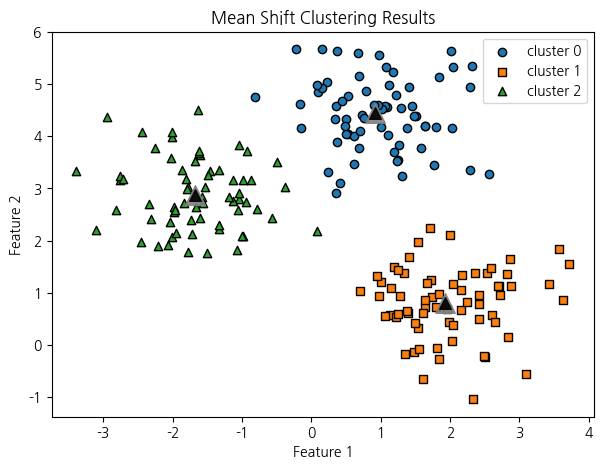

In [ ]:

# Define a list of markers for plotting
marker = ['o', 's', '^', 'v', '<']

X_ms, y_ms = make_blobs( # 가우시안 분포 기반 군집형 합성 데이터 생성
    n_samples=200, n_features=2, centers=3, #생성할 군집의 개수
    cluster_std=0.7, random_state=0 #각 군집 내 데이터 포인트들의 표준 편차, 값이 작으면 군집이 조밀하고, 크면 넓게 퍼지는
                         )
# bandwidth 값에 따른 군집 수 변화 비교
print('=== bandwidth 영향 비교 ===')
for bw in [0.8,1.0]:
  ms = MeanShift(bandwidth=bw)
  labels_ms = ms.fit_predict(X_ms)
  print(f'bandwidth={bw} : 군집 수={len(np.unique(labels_ms))}') # Fix: Missing argument for np.unique
  # estimate_bandwidth: 최적 bandwidth 자동 추정
  # KDE(커널 밀도 추정)를 사용하여 데이터 분포에 맞는 bandwidth 자동 개선
  best_bandwidth = estimate_bandwidth(X_ms) # Fix: estimeate_bandwidth -> estimate_bandwidth
  print(f'estimate_bandwidth 추정값: {best_bandwidth:.3f}') # Fix: SyntaxError with f-string

  #최적 bandwidth로 Mean Sifht 적용
  meanshift  = MeanShift(bandwidth=best_bandwidth) # Fix: Meanshift -> MeanShift
  # meenShift는 각 데이터 포인트 주변의 밀도가 높은 방향으로 중심을 이동시켜 최종 군집 중심(밀도 봉우리)을 찾는다
  cluster_labels_ms = meanshift.fit_predict(X_ms)
  print(f'최적 bandwidth 적용 군집 수: {len(np.unique(cluster_labels_ms))}') # Fix: prinr -> print, extra parenthesis

  clusterDf_ms = pd.DataFrame(data=X_ms, columns=['feature1', 'feature2'])
  clusterDf_ms['target'] = y_ms
  clusterDf_ms['meanshift_label'] = cluster_labels_ms

# mean shift 결과 시각화
centers_ms = meanshift.cluster_centers_ #수렴된 군집 중심 좌표
unique_labels_ms = np.unique(cluster_labels_ms) # Fix: Extra closing parenthesis
markers = ['a', 's', '^', 'p', 'o','h','x'] # Fix: unterminated string literal
plt.figure(figsize=(7, 5))
for label in unique_labels_ms: #[0,1,2]
  ic = clusterDf_ms[clusterDf_ms['meanshift_label'] == label]
  plt.scatter(ic['feature1'], ic['feature2'],
              edgecolor='k', marker=marker[label % 5], label=f'cluster {label}')

# Define cx and cy from centers_ms
cx = centers_ms[:, 0]
cy = centers_ms[:, 1]

#회색 큰 원 밀도 기반으로 수렴한 중심점 표시
plt.scatter(cx, cy, s=200, color='gray' , alpha=0.9, marker=markers[label %5])
plt.scatter(cx,cy, s=70, color='k', alpha=0.9, marker=markers[label %5])
plt.title('Mean Shift Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### GMM (가우시안 혼합 모델)
[GMM이란?]
* 데이터가 여러 개의 가우시안(정규) 분포의 혼합으로 생성됐다고 가정
* EM(Expectation-Maximization) 알고리즘으로 파라미터 추정

[K-Means vs GMM 핵심 차이]
* K-Means: 각 데이터가 하나의 군집에만 속함 (Hard Assignment), 원형(구형) 군집 가정
*  GMM    : 각 데이터가 모든 군집에 확률로 속함 (Soft Assignment), 타원형 군집도 모델링 가능 (공분산 행렬로 방향·크기 추정)

[GMM이 K-Means보다 유리한 경우]
* 타원형으로 늘어진 군집, 군집 크기·방향이 다른 경우
* 데이터가 진짜 혼합 가우시안 분포를 따르는 경우

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3, #가우시안 분포 수 (=군집 수))
    random_state=0
)
gmm.fit(iris.data) # EM 알고리즘으ㅗ 각 가우시안 파라미터 추정
gmm.cluster_labels = gmm.predict(iris.data) # 가장 확률이 높은 군집으로 hard 할당
# gmm.predict_proba(iris.data); 각 군집에 속할 확률도 반환가능

irisDF['gmm_cluster'] = gmm.cluster_labels

print('=== gmm군집 결과 ===')
print(irisDF.groupby(['target', 'gmm_cluster'])['sepal_length'].count())

=== gmm군집 결과 ===
target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: sepal_length, dtype: int64


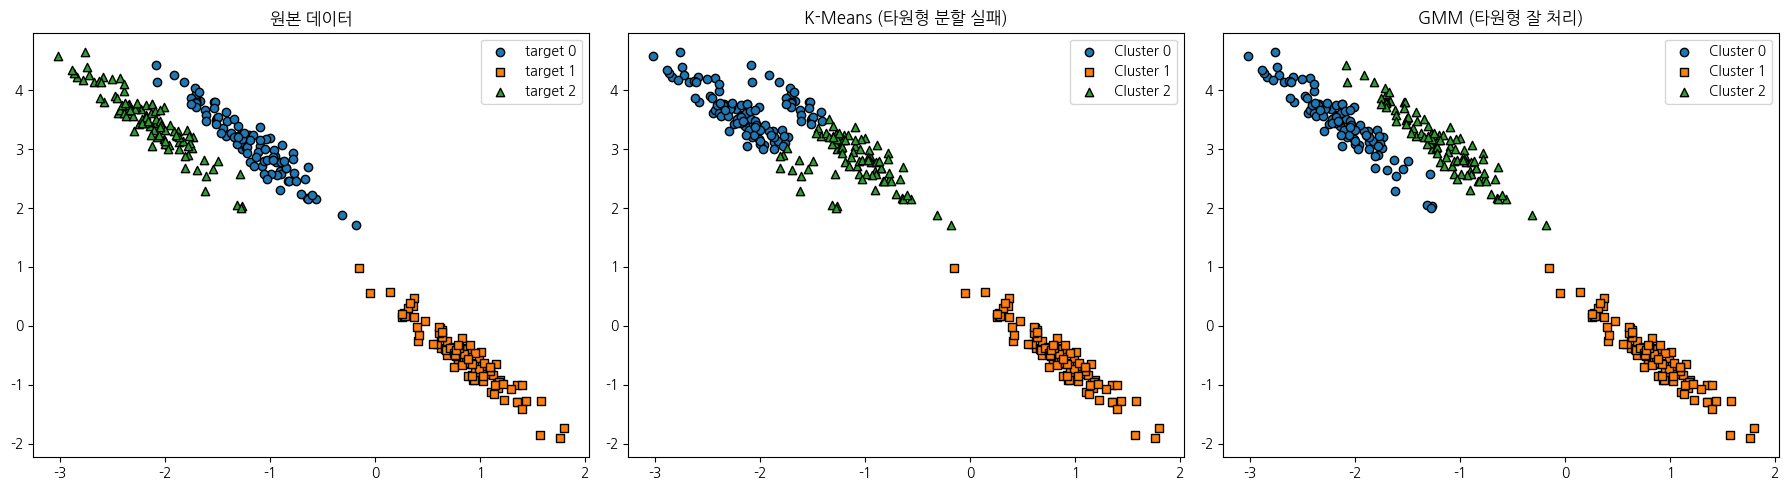


==== k-means 결과 ====
target  kmean_label
0       2               73
        0               27
1       1              100
2       0               86
        2               14
Name: count, dtype: int64

==== GMM 결과 ====
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


In [ ]:
#타원형 데이터: gmm Vs k-means 강점 비교
from sklearn.cluster import KMeans

X_blob, y_blob = make_blobs(
    n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0
)
#선형 변환으로 원형 > 타원형 변환
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X_blob, transformation)

clusterDf_an = pd.DataFrame(X_aniso, columns=['ftr1', 'ftr2'])
clusterDf_an['target'] = y_blob

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
marker = ['o', 's', '^']

#원본 타원형 데이터
for i in range(3):
    mask = clusterDf_an['target'] == i
    axes[0].scatter(clusterDf_an.loc[mask, 'ftr1'],
                    clusterDf_an.loc[mask, 'ftr2'],
                    marker=marker[i], edgecolor='k', label=f'target {i}')
axes[0].set_title('원본 데이터')
axes[0].legend()

# k-Means (타원형에 취약)
km_an = KMeans(3, random_state=0)
clusterDf_an['kmean_label'] = km_an.fit_predict(X_aniso)
for i in range(3):
    mask = clusterDf_an['kmean_label'] == i
    axes[1].scatter(clusterDf_an.loc[mask, 'ftr1'],
                    clusterDf_an.loc[mask, 'ftr2'],
                    marker=marker[i], edgecolor='k', label=f'Cluster {i}')
axes[1].set_title('K-Means (타원형 분할 실패)')
axes[1].legend()

# GMM (타원형 잘 처리)
gmm_an = GaussianMixture(n_components=3, random_state=0)
clusterDf_an['gmm_label'] = gmm_an.fit_predict(X_aniso)
for i in range(3):
    mask = clusterDf_an['gmm_label'] == i
    axes[2].scatter(clusterDf_an.loc[mask, 'ftr1'],
                    clusterDf_an.loc[mask, 'ftr2'],
                    marker=marker[i], edgecolor='k', label=f'Cluster {i}')
axes[2].set_title('GMM (타원형 잘 처리)')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\n==== k-means 결과 ====')
print(clusterDf_an.groupby('target')['kmean_label'].value_counts())
print('\n==== GMM 결과 ====')
print(clusterDf_an.groupby('target')['gmm_label'].value_counts())